## Task 1-Data Preparation and Customer Analytics

Conduct analysis on your client's transaction dataset and identify customer purchasing behaviours to generate insights and provide commercial recommendations.

Background information for the task

We need to present a strategic recommendation to Julia that is supported by data which she can then use for the upcoming category review however to do so we need to analyse the data to understand the current purchasing trends and behaviours. The client is particularly interested in customer segments and their chip purchasing behaviour. Consider what metrics would help describe the customers’ purchasing behaviour.

Main goals of this task are :

1. Examine transaction data - check for missing data, anomalies, outliers and clean them
2. Examine customer data - similar to above transaction data
3. Data analysis and customer segments - create charts and graphs, note trends and insights
4. Deep dive into customer segments - determine which segments should be targetted

In [1]:
import pandas as pd
import numpy as np
import datetime as dt
import matplotlib.pyplot as plt
import seaborn as sns
     

In [2]:
df = pd.read_excel(r'C:\Users\karan\Desktop\Projectt\Quantium\QVI_transaction_data.xlsx')
df.head()

,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_NAME,PROD_QTY,TOT_SALES
0,2018-10-17,1,1000,1,5,Natural Chip Compny SeaSalt175g,2,6.0
1,2019-05-14,1,1307,348,66,CCs Nacho Cheese 175g,3,6.3
2,2019-05-20,1,1343,383,61,Smiths Crinkle Cut Chips Chicken 170g,2,2.9
3,2018-08-17,2,2373,974,69,Smiths Chip Thinly S/Cream&Onion 175g,5,15.0
4,2018-08-18,2,2426,1038,108,Kettle Tortilla ChpsHny&Jlpno Chili 150g,3,13.8


In [3]:
df.isnull().sum()

DATE              0
STORE_NBR         0
LYLTY_CARD_NBR    0
TXN_ID            0
PROD_NBR          0
PROD_NAME         0
PROD_QTY          0
TOT_SALES         0
dtype: int64

In [4]:
df.describe()

,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_QTY,TOT_SALES
count,264836,264836.00000,2.648360e+05,2.648360e+05,264836.000000,264836.000000,264836.000000
mean,2018-12-30 00:52:12.879215616,135.08011,1.355495e+05,1.351583e+05,56.583157,1.907309,7.304200
min,2018-07-01 00:00:00,1.00000,1.000000e+03,1.000000e+00,1.000000,1.000000,1.500000
25%,2018-09-30 00:00:00,70.00000,7.002100e+04,6.760150e+04,28.000000,2.000000,5.400000
50%,2018-12-30 00:00:00,130.00000,1.303575e+05,1.351375e+05,56.000000,2.000000,7.400000
75%,2019-03-31 00:00:00,203.00000,2.030942e+05,2.027012e+05,85.000000,2.000000,9.200000
max,2019-06-30 00:00:00,272.00000,2.373711e+06,2.415841e+06,114.000000,200.000000,650.000000
std,NaN,76.78418,8.057998e+04,7.813303e+04,32.826638,0.643654,3.083226


In [5]:
df.duplicated().sum()

np.int64(1)

In [6]:
df.drop_duplicates(inplace=True)

In [7]:
df.duplicated().sum()

np.int64(0)

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 264835 entries, 0 to 264835
Data columns (total 8 columns):
 #   Column          Non-Null Count   Dtype         
---  ------          --------------   -----         
 0   DATE            264835 non-null  datetime64[ns]
 1   STORE_NBR       264835 non-null  int64         
 2   LYLTY_CARD_NBR  264835 non-null  int64         
 3   TXN_ID          264835 non-null  int64         
 4   PROD_NBR        264835 non-null  int64         
 5   PROD_NAME       264835 non-null  object        
 6   PROD_QTY        264835 non-null  int64         
 7   TOT_SALES       264835 non-null  float64       
dtypes: datetime64[ns](1), float64(1), int64(5), object(1)
memory usage: 18.2+ MB


In [12]:
df.shape

(264257, 8)

### Outliers


In [9]:
# Step 1: Calculate IQR
Q1 = df['TOT_SALES'].quantile(0.25)
Q3 = df['TOT_SALES'].quantile(0.75)
IQR = Q3 - Q1

# Step 2: Define bounds
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Step 3: Remove outliers 
df = df[
    (df['TOT_SALES'] >= lower_bound) &
    (df['TOT_SALES'] <= upper_bound)
]


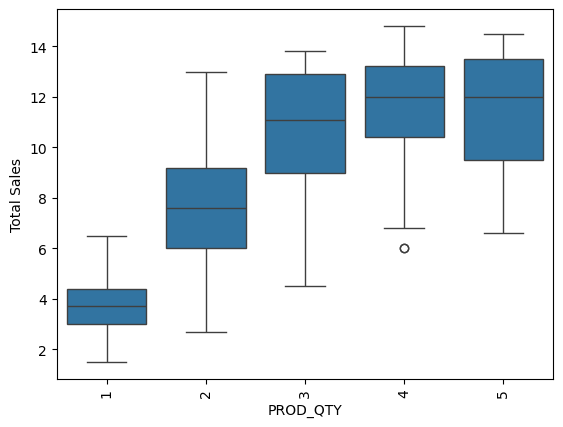

In [10]:
# PLot Boxplot 

sns.boxplot(y='TOT_SALES', x='PROD_QTY', data=df)
plt.xticks(rotation=90)
plt.ylabel('Total Sales')
plt.show()

In [11]:
print("Shape of Dataset after removing outliers:", df.shape)

Shape of Dataset after removing outliers: (264257, 8)


# Purchase Behaviour

In [13]:
pur_bvr = pd.read_csv(r'C:\Users\karan\Desktop\Projectt\Quantium\QVI_purchase_behaviour.csv')
pur_bvr.head()

,LYLTY_CARD_NBR,LIFESTAGE,PREMIUM_CUSTOMER
0,1000,YOUNG SINGLES/COUPLES,Premium
1,1002,YOUNG SINGLES/COUPLES,Mainstream
2,1003,YOUNG FAMILIES,Budget
3,1004,OLDER SINGLES/COUPLES,Mainstream
4,1005,MIDAGE SINGLES/COUPLES,Mainstream


In [15]:
pur_bvr.describe()

,LYLTY_CARD_NBR
count,7.263700e+04
mean,1.361859e+05
std,8.989293e+04
min,1.000000e+03
25%,6.620200e+04
50%,1.340400e+05
75%,2.033750e+05
max,2.373711e+06


In [16]:
pur_bvr.isnull().sum()

LYLTY_CARD_NBR      0
LIFESTAGE           0
PREMIUM_CUSTOMER    0
dtype: int64

### Merge Data

In [17]:
merged_df = pd.merge(df, pur_bvr, on='LYLTY_CARD_NBR', how='right')
merged_df.head()

,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_NAME,PROD_QTY,TOT_SALES,LIFESTAGE,PREMIUM_CUSTOMER
0,2018-10-17,1.0,1000,1.0,5.0,Natural Chip Compny SeaSalt175g,2.0,6.0,YOUNG SINGLES/COUPLES,Premium
1,2018-09-16,1.0,1002,2.0,58.0,Red Rock Deli Chikn&Garlic Aioli 150g,1.0,2.7,YOUNG SINGLES/COUPLES,Mainstream
2,2019-03-07,1.0,1003,3.0,52.0,Grain Waves Sour Cream&Chives 210G,1.0,3.6,YOUNG FAMILIES,Budget
3,2019-03-08,1.0,1003,4.0,106.0,Natural ChipCo Hony Soy Chckn175g,1.0,3.0,YOUNG FAMILIES,Budget
4,2018-11-02,1.0,1004,5.0,96.0,WW Original Stacked Chips 160g,1.0,1.9,OLDER SINGLES/COUPLES,Mainstream


In [18]:
merged_df.shape

(264306, 10)

In [19]:
merged_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 264306 entries, 0 to 264305
Data columns (total 10 columns):
 #   Column            Non-Null Count   Dtype         
---  ------            --------------   -----         
 0   DATE              264257 non-null  datetime64[ns]
 1   STORE_NBR         264257 non-null  float64       
 2   LYLTY_CARD_NBR    264306 non-null  int64         
 3   TXN_ID            264257 non-null  float64       
 4   PROD_NBR          264257 non-null  float64       
 5   PROD_NAME         264257 non-null  object        
 6   PROD_QTY          264257 non-null  float64       
 7   TOT_SALES         264257 non-null  float64       
 8   LIFESTAGE         264306 non-null  object        
 9   PREMIUM_CUSTOMER  264306 non-null  object        
dtypes: datetime64[ns](1), float64(5), int64(1), object(3)
memory usage: 20.2+ MB


### Checking the product name column to make sure all items are chips

In [21]:
merged_df['PROD_NAME'].unique()

array(['Natural Chip        Compny SeaSalt175g',
       'Red Rock Deli Chikn&Garlic Aioli 150g',
       'Grain Waves Sour    Cream&Chives 210G',
       'Natural ChipCo      Hony Soy Chckn175g',
       'WW Original Stacked Chips 160g', 'Cheetos Puffs 165g',
       'Infuzions SourCream&Herbs Veg Strws 110g',
       'RRD SR Slow Rst     Pork Belly 150g',
       'Doritos Cheese      Supreme 330g', 'Doritos Mexicana    170g',
       'Old El Paso Salsa   Dip Tomato Med 300g',
       'GrnWves Plus Btroot & Chilli Jam 180g',
       'Smiths Crinkle Cut  Chips Barbecue 170g',
       'Kettle Sensations   Camembert & Fig 150g',
       'Doritos Corn Chip Southern Chicken 150g',
       'CCs Tasty Cheese    175g', 'Tostitos Splash Of  Lime 175g',
       'Kettle 135g Swt Pot Sea Salt', 'RRD Salt & Vinegar  165g',
       'Infuzions Mango     Chutny Papadums 70g',
       'Smiths Crinkle Cut  Snag&Sauce 150g',
       'Smiths Crinkle      Original 330g',
       'RRD Sweet Chilli &  Sour Cream 165g',
     

In [42]:
split_prods = (merged_df['PROD_NAME']
               .dropna()
               .str.replace(r'([0-9]+[gG])', '', regex=True)
               .str.replace(r'[^\w]', ' ', regex=True)
               .str.split())

In [43]:
word_counts = {}
def count_words(line):
  for word in line:
    if word not in word_counts:
      word_counts[word] = 1
    else:
      word_counts[word] += 1
split_prods.apply(lambda line: count_words(line))
print(pd.Series(word_counts).sort_values(ascending = False))

Chips     49688
Kettle    41141
Smiths    28809
Salt      27924
Cheese    27809
          ...  
Frch       1432
Pc         1429
Fries      1418
NCC        1416
Garden     1416
Length: 198, dtype: int64


In [44]:
print(merged_df.describe(), '\n')
print(merged_df.info())

                                DATE      STORE_NBR  LYLTY_CARD_NBR  \
count                         264257  264257.000000    2.643060e+05   
mean   2018-12-30 00:57:22.176366592     135.076153    1.355412e+05   
min              2018-07-01 00:00:00       1.000000    1.000000e+03   
25%              2018-09-30 00:00:00      70.000000    7.001800e+04   
50%              2018-12-30 00:00:00     130.000000    1.303560e+05   
75%              2019-03-31 00:00:00     203.000000    2.030920e+05   
max              2019-06-30 00:00:00     272.000000    2.373711e+06   
std                              NaN      76.785525    8.058909e+04   

             TXN_ID       PROD_NBR       PROD_QTY      TOT_SALES  
count  2.642570e+05  264257.000000  264257.000000  264257.000000  
mean   1.351547e+05      56.589820       1.900275       7.272280  
min    1.000000e+00       1.000000       1.000000       1.500000  
25%    6.759600e+04      28.000000       2.000000       5.400000  
50%    1.351360e+05      

In [48]:
bins = [0.8, 50.75, 100.5, 150.25, 200.0]

result = pd.cut(merged_df["PROD_QTY"], bins=bins) \
           .value_counts() \
           .sort_index()

print(result)

PROD_QTY
(0.8, 50.75]       264257
(50.75, 100.5]          0
(100.5, 150.25]         0
(150.25, 200.0]         0
Name: count, dtype: int64


In [60]:
merged_df["DATE"].nunique()

364

#### There are 365 days in a year but in the DATE column there are only 364 unique values so one is missing

In [61]:
pd.date_range(start=merged_df["DATE"].min(), end=merged_df["DATE"].max()).difference(merged_df["DATE"])

DatetimeIndex(['2018-12-25'], dtype='datetime64[ns]', freq='D')

### 
Using the difference method we see that 2018-12-25 was a missing date

In [63]:


check_null_date = pd.merge(pd.Series(pd.date_range(start=merged_df["DATE"].min(), end = merged_df["DATE"].max()), name="DATE"), merged_df, on = "DATE", how = "left")

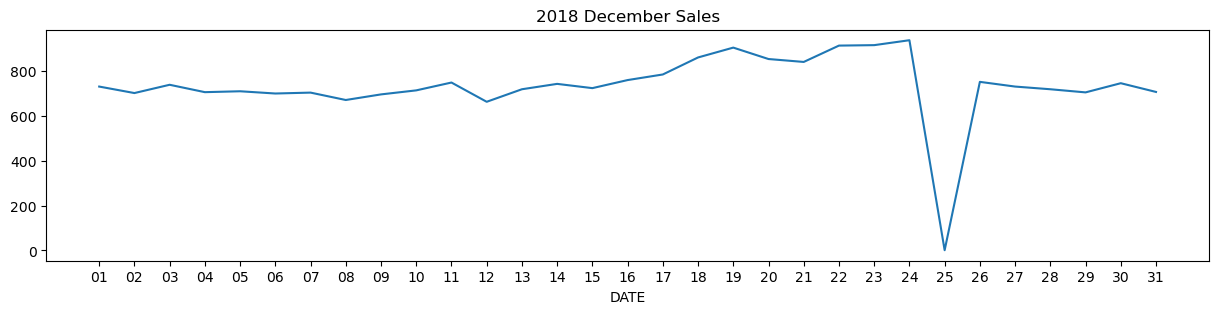

In [68]:
trans_by_date = check_null_date["DATE"].value_counts()

dec = trans_by_date[(trans_by_date.index >= pd.Timestamp(2018, 12, 1)) & (trans_by_date.index < pd.Timestamp(2019, 1,1))].sort_index()

dec.index = dec.index.strftime('%d')
# Plot
ax = dec.plot(figsize=(15, 3))
ax.set_xticks(np.arange(len(dec)))
ax.set_xticklabels(dec.index)

plt.title("2018 December Sales")
plt.savefig("2018 December Sales.png", bbox_inches="tight")
plt.show()


#### The day with no transaction is a Christmas day that is when the store is closed. So there is no anomaly in this.

#### 
Explore Packet sizes

count    264257.000000
mean        182.382995
std          64.287036
min          70.000000
25%         150.000000
50%         170.000000
75%         175.000000
max         380.000000
Name: 0, dtype: float64


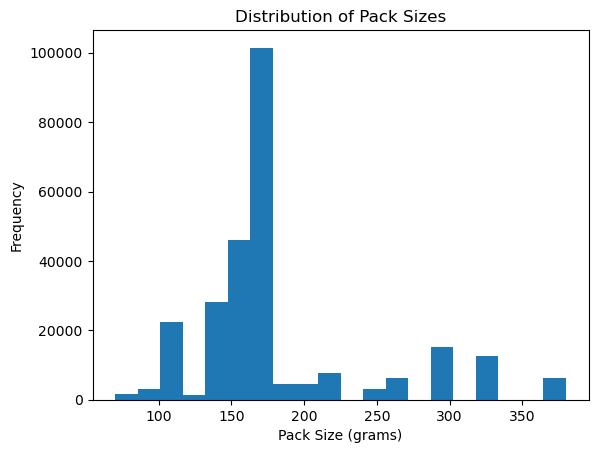

In [69]:
merged_df["PROD_NAME"] = merged_df["PROD_NAME"].str.replace(r'([0-9]+)G', r'\1g', regex=True)

# Step 2: Extract pack size (e.g., 100g, 250g)
pack_sizes = merged_df["PROD_NAME"].str.extract(r'([0-9]+[gG])')[0]

# Step 3: Remove 'g' or 'G' and convert to numeric
pack_sizes = pack_sizes.str.replace(r'[gG]', '', regex=True).astype(float)

# Step 4: Print summary statistics
print(pack_sizes.describe())

# Step 5: Plot histogram
plt.figure()
pack_sizes.plot.hist(bins=20)
plt.title("Distribution of Pack Sizes")
plt.xlabel("Pack Size (grams)")
plt.ylabel("Frequency")
plt.show()

In [70]:
merged_df['PROD_NAME'].str.split().str[0].value_counts().sort_index()   

PROD_NAME
Burger         1564
CCs            4551
Cheetos        2926
Cheezels       4583
Cobs           9669
Dorito         3175
Doritos       24896
French         1418
Grain          6265
GrnWves        1465
Infuzions     11035
Infzns         3138
Kettle        41141
NCC            1416
Natural        6037
Old            9284
Pringles      25052
RRD           11880
Red            5885
Smith          2963
Smiths        28809
Snbts          1576
Sunbites       1432
Thins         14049
Tostitos       9443
Twisties       9420
Tyrrells       6428
WW            10320
Woolworths     4437
Name: count, dtype: int64


Some product names are written in more than one way. Example : Dorito and Doritos, Grains and GrnWves, Infusions and Ifzns, Natural and NCC, Red and RRD, Smith and Smiths and Snbts and Sunbites.

In [75]:
merged_df['cleaned_brand_name'] = merged_df['PROD_NAME'].str.split().str[0]

In [79]:

def clean_brand_names(line):
    brand = line["cleaned_brand_name"]
    if brand == "Dorito":
        return "Doritos"
    elif brand == "GrnWves" or brand == "Grain":
        return "Grain Waves"
    elif brand == "Infzns":
        return "Infuzions"
    elif brand == "Natural" or brand == "NCC":
        return "Natural Chip Co"
    elif brand == "Red":
        return "RRD"
    elif brand == "Smith":
        return "Smiths"
    elif brand == "Snbts":
        return "Sunbites"
    elif brand == "WW":
        return "Woolworths"
    else:
        return brand

In [80]:
merged_df['cleaned_brand_name'] = merged_df.apply(lambda line: clean_brand_names(line), axis=1)

<Axes: ylabel='cleaned_brand_name'>

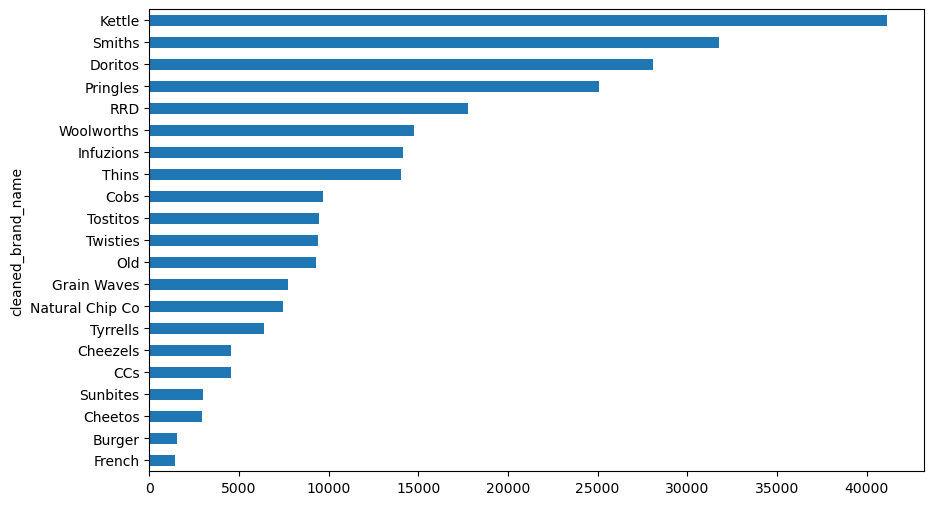

In [83]:
merged_df['cleaned_brand_name'].value_counts(ascending  =True).plot.barh(figsize=(10, 6) )

1. Who spends the most on chips (total sales), describing customers by lifestage and how premium their general purchasing behaviour is 
2. .How many customers are in each segment
3. How many chips are bought per customer by segment
4. What's the average chip price by customer segment

In [92]:
grouped_sales = pd.DataFrame(merged_df.groupby(["LIFESTAGE", "PREMIUM_CUSTOMER"])["TOT_SALES"].agg(["sum","mean"]))
grouped_sales.sort_values(ascending=False, by = "sum")

sum      mean
LIFESTAGE              PREMIUM_CUSTOMER                     
OLDER FAMILIES         Budget            167213.95  7.237446
YOUNG SINGLES/COUPLES  Mainstream        156882.00  7.536606
RETIREES               Mainstream        155033.45  7.233399
YOUNG FAMILIES         Budget            138388.20  7.256093
OLDER SINGLES/COUPLES  Budget            135858.90  7.399319
                       Mainstream        132618.30  7.254830
                       Premium           131487.95  7.421989
RETIREES               Budget            112415.70  7.413328
OLDER FAMILIES         Mainstream        102668.80  7.228161
RETIREES               Premium            97118.50  7.430074
YOUNG FAMILIES         Mainstream         92154.75  7.158763
MIDAGE SINGLES/COUPLES Mainstream         90178.20  7.614473
YOUNG FAMILIES         Premium            83553.90  7.241000
OLDER FAMILIES         Premium            80062.50  7.175345
YOUNG SINGLES/COUPLES  Budget             60937.60  6.601408
MIDAGE SINGLES/COUPLES Premium            58095.55  7.085687
YOUNG SINGLES/COUPLES  Premium            41520.40  6.617851
MIDAGE SINGLES/COUPLES Budget             35309.20  7.049152
NEW FAMILIES           Budget             21862.25  7.282562
                       Mainstream         16940.35  7.298729
                       Premium            11450.50  7.215186

<Axes: ylabel='LIFESTAGE,PREMIUM_CUSTOMER'>

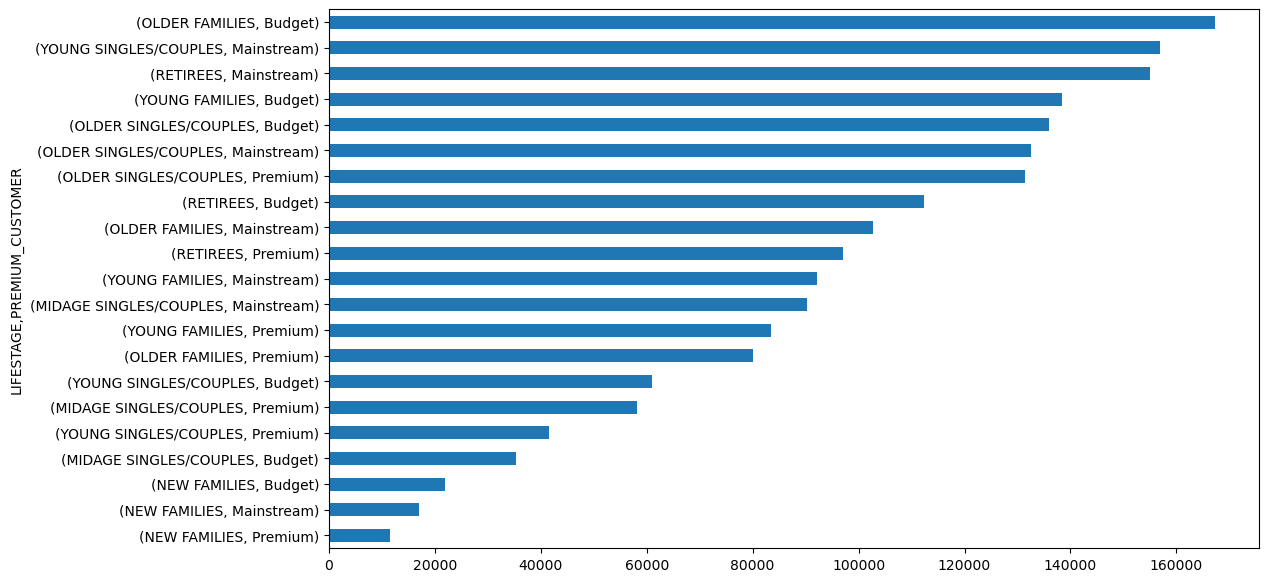

In [93]:
grouped_sales["sum"].sort_values().plot.barh(figsize=(12, 7))

C:\Users\karan\AppData\Local\Temp\ipykernel_15096\3463873474.py:26: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  left[i] + val / 2,


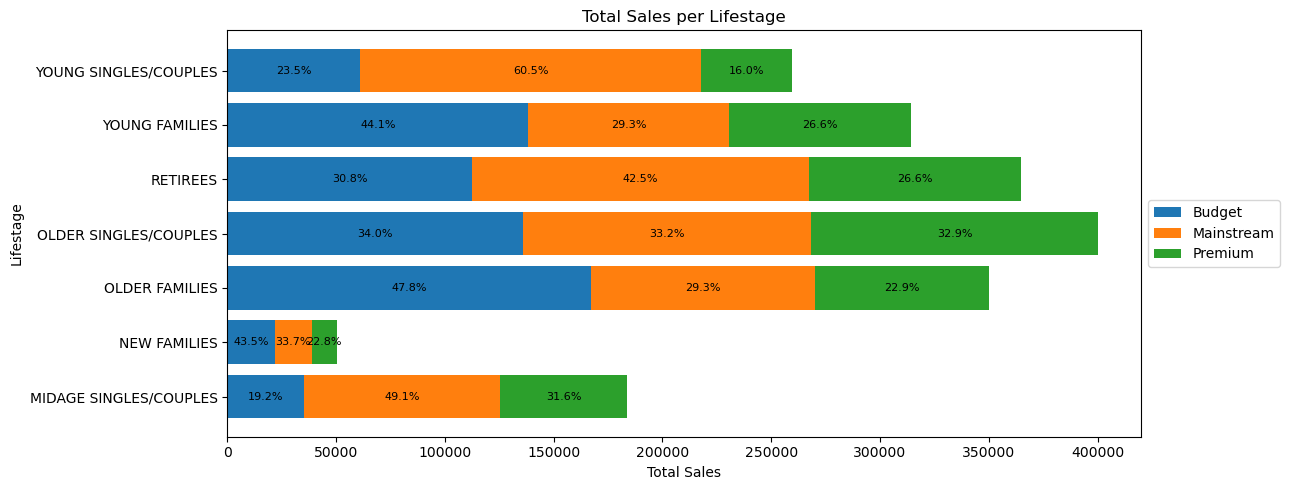

In [94]:
# Convert to pivot format (BEST PRACTICE)
pivot_df = grouped_sales.reset_index().pivot(
    index="LIFESTAGE",
    columns="PREMIUM_CUSTOMER",
    values="sum"
).fillna(0)

# Ensure correct column order
pivot_df = pivot_df[["Budget", "Mainstream", "Premium"]]

# Convert to percentage
percent_df = pivot_df.div(pivot_df.sum(axis=1), axis=0)

# Plot
fig, ax = plt.subplots(figsize=(13, 5))

left = np.zeros(len(pivot_df))

for col in pivot_df.columns:
    bars = ax.barh(pivot_df.index, pivot_df[col], left=left, label=col)
    
    # Add percentage labels
    for i, (val, pct) in enumerate(zip(pivot_df[col], percent_df[col])):
        if val > 0:
            ax.text(
                left[i] + val / 2,
                i,
                f"{pct:.1%}",
                ha='center',
                va='center',
                fontsize=8
            )
    
    left += pivot_df[col]

# Labels & formatting
ax.set_xlabel("Total Sales")
ax.set_ylabel("Lifestage")
ax.set_title("Total Sales per Lifestage")
ax.legend(loc='center left', bbox_to_anchor=(1.0, 0.5))

plt.tight_layout()
plt.savefig("lifestage_sales.png")
plt.show()

In [95]:
# Find most common PREMIUM_CUSTOMER type per LIFESTAGE
stage_agg_prem = (
    merged_df
    .groupby("LIFESTAGE")["PREMIUM_CUSTOMER"]
    .agg(lambda x: x.value_counts().idxmax())
    .reset_index(name="Top_Premium_Category")
)

print("Most common PREMIUM_CUSTOMER segment for each LIFESTAGE:")
print(stage_agg_prem)

Most common PREMIUM_CUSTOMER segment for each LIFESTAGE:
                LIFESTAGE Top_Premium_Category
0  MIDAGE SINGLES/COUPLES           Mainstream
1            NEW FAMILIES               Budget
2          OLDER FAMILIES               Budget
3   OLDER SINGLES/COUPLES               Budget
4                RETIREES           Mainstream
5          YOUNG FAMILIES               Budget
6   YOUNG SINGLES/COUPLES           Mainstream


The top 3 total sales contributor segment are (in order):

1. Older families (Budget) 
2. Young Singles/Couples (Mainstream)
3. Retirees (Mainstream)

In [97]:
unique_cust = merged_df.groupby(["LIFESTAGE","PREMIUM_CUSTOMER"])["LYLTY_CARD_NBR"].nunique().sort_values(ascending=False)
pd.DataFrame(unique_cust)

LYLTY_CARD_NBR
LIFESTAGE              PREMIUM_CUSTOMER                
YOUNG SINGLES/COUPLES  Mainstream                  8088
RETIREES               Mainstream                  6479
OLDER SINGLES/COUPLES  Mainstream                  4930
                       Budget                      4929
                       Premium                     4750
OLDER FAMILIES         Budget                      4675
RETIREES               Budget                      4454
YOUNG FAMILIES         Budget                      4017
RETIREES               Premium                     3872
YOUNG SINGLES/COUPLES  Budget                      3779
MIDAGE SINGLES/COUPLES Mainstream                  3340
OLDER FAMILIES         Mainstream                  2831
YOUNG FAMILIES         Mainstream                  2728
YOUNG SINGLES/COUPLES  Premium                     2574
YOUNG FAMILIES         Premium                     2433
MIDAGE SINGLES/COUPLES Premium                     2431
OLDER FAMILIES         Premium                     2274
MIDAGE SINGLES/COUPLES Budget                      1504
NEW FAMILIES           Budget                      1112
                       Mainstream                   849
                       Premium                      588

<Axes: ylabel='LIFESTAGE,PREMIUM_CUSTOMER'>

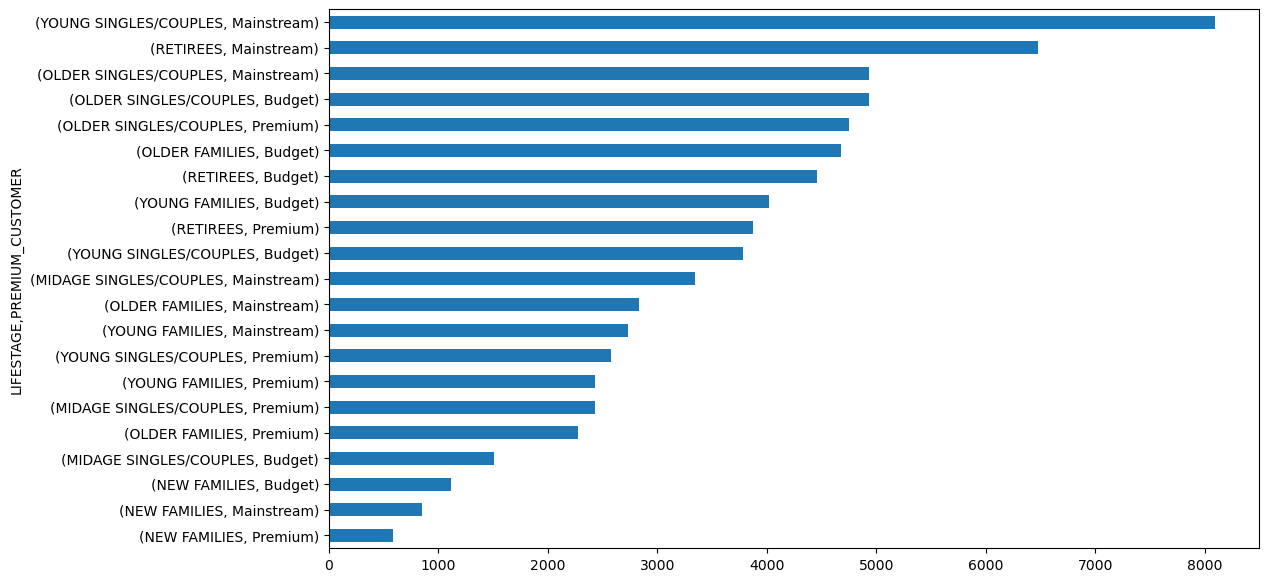

In [98]:
unique_cust.sort_values().plot.barh(figsize=(12, 7))

C:\Users\karan\AppData\Local\Temp\ipykernel_15096\4256710511.py:27: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  ax.text(left[i] + val/2, i, f"{pct:.1%}", ha='center', va='center', fontsize=8)


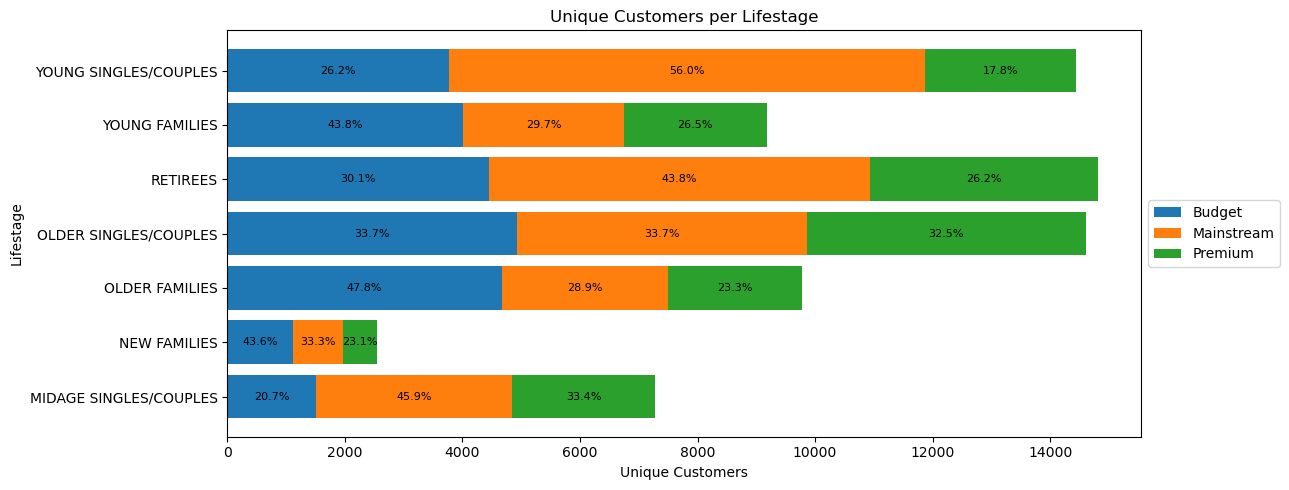

In [100]:
# Convert Series → DataFrame safely
unique_cust_df = unique_cust.reset_index(name="CUSTOMERS")

# Pivot
pivot_df = unique_cust_df.pivot(
    index="LIFESTAGE",
    columns="PREMIUM_CUSTOMER",
    values="CUSTOMERS"
).fillna(0)

# Safe column ordering
pivot_df = pivot_df.reindex(columns=["Budget", "Mainstream", "Premium"], fill_value=0)

# Percentages
percent_df = pivot_df.div(pivot_df.sum(axis=1), axis=0)

# Plot
fig, ax = plt.subplots(figsize=(13, 5))

left = np.zeros(len(pivot_df))

for col in pivot_df.columns:
    bars = ax.barh(pivot_df.index, pivot_df[col], left=left, label=col)
    
    for i, (val, pct) in enumerate(zip(pivot_df[col], percent_df[col])):
        if val > 0:
            ax.text(left[i] + val/2, i, f"{pct:.1%}", ha='center', va='center', fontsize=8)
    
    left += pivot_df[col]

ax.set_xlabel("Unique Customers")
ax.set_ylabel("Lifestage")
ax.set_title("Unique Customers per Lifestage")
ax.legend(loc='center left', bbox_to_anchor=(1.0, 0.5))

plt.tight_layout()
plt.savefig("lifestage_customers.png")
plt.show()


The high sales amount by segment "Young Singles/Couples - Mainstream" and "Retirees - Mainstream" are due to their large number of unique customers, but not for the "Older - Budget" segment. Next we'll explore if the "Older - Budget" segment has:

High Frequency of Purchase and, Average Sales per Customer compared to the other segment.

In [101]:
segement_metrics = (merged_df.groupby(["LIFESTAGE", "PREMIUM_CUSTOMER"])
                    .agg(total_transactions = ("DATE", "count"),
                         total_customers = ("LYLTY_CARD_NBR", "nunique"),
                         total_sales = ("TOT_SALES", "sum")
                )
            .reset_index()
)

In [102]:
segement_metrics["freq_per_customer"] = (segement_metrics["total_transactions"] / segement_metrics["total_customers"])

segement_metrics["avg_sales_per_customer"] = (segement_metrics["total_sales"] / segement_metrics["total_customers"])

In [103]:
segement_metrics.sort_values("freq_per_customer", ascending=False)

,LIFESTAGE,PREMIUM_CUSTOMER,total_transactions,total_customers,total_sales,freq_per_customer,avg_sales_per_customer
7,OLDER FAMILIES,Mainstream,14204,2831,102668.80,5.017308,36.265913
6,OLDER FAMILIES,Budget,23104,4675,167213.95,4.942032,35.767690
8,OLDER FAMILIES,Premium,11158,2274,80062.50,4.906772,35.207784
15,YOUNG FAMILIES,Budget,19072,4017,138388.20,4.747822,34.450635
17,YOUNG FAMILIES,Premium,11539,2433,83553.90,4.742704,34.341924
16,YOUNG FAMILIES,Mainstream,12873,2728,92154.75,4.718842,33.781067
11,OLDER SINGLES/COUPLES,Premium,17716,4750,131487.95,3.729684,27.681674
9,OLDER SINGLES/COUPLES,Budget,18361,4929,135858.90,3.725096,27.563177
10,OLDER SINGLES/COUPLES,Mainstream,18280,4930,132618.30,3.707911,26.900264
1,MIDAGE SINGLES/COUPLES,Mainstream,11843,3340,90178.20,3.545808,26.999461


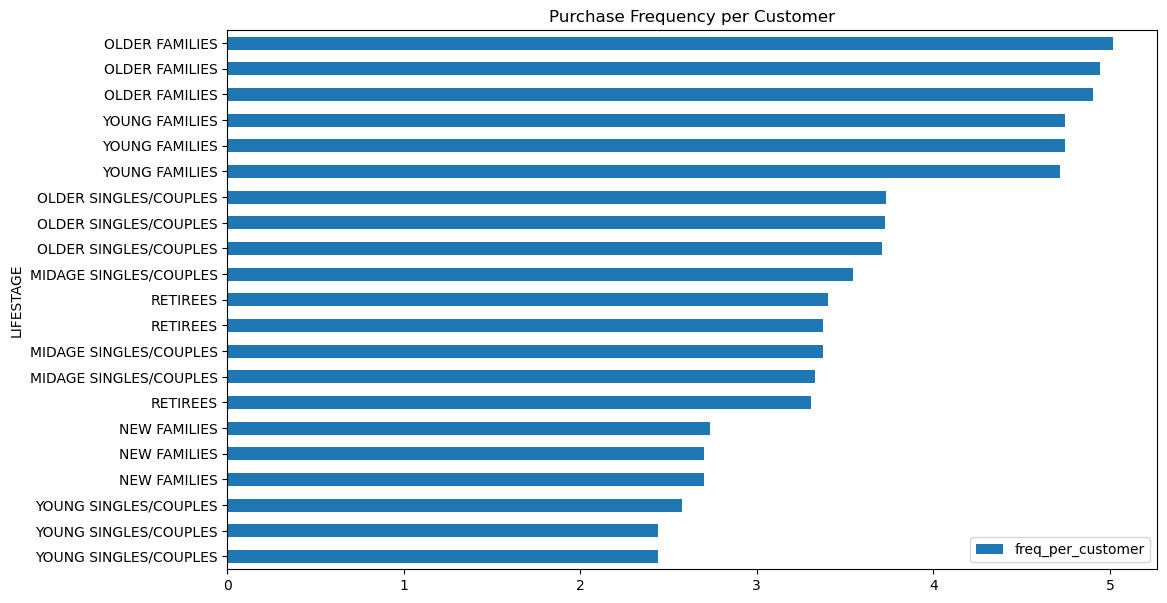

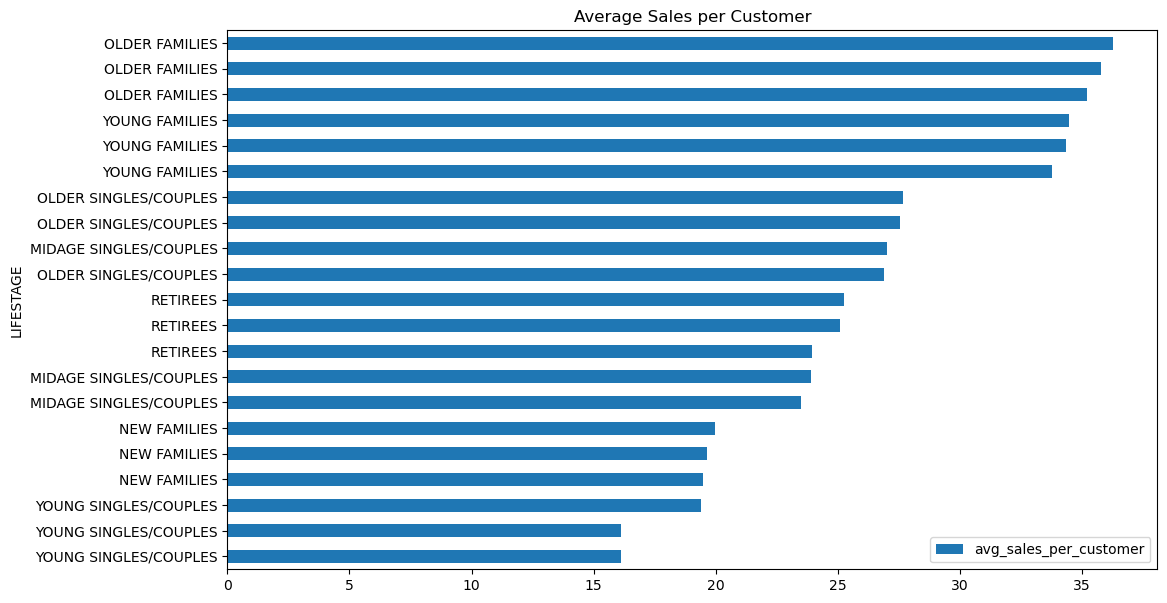

In [106]:
# Frequency plot
segement_metrics.sort_values("freq_per_customer").plot(
    x="LIFESTAGE",
    y="freq_per_customer",
    kind="barh",
    figsize=(12,7),
    title="Purchase Frequency per Customer"
)
plt.show()

# Avg spend plot
segement_metrics.sort_values("avg_sales_per_customer").plot(
    x="LIFESTAGE",
    y="avg_sales_per_customer",
    kind="barh",
    figsize=(12,7),
    title="Average Sales per Customer"
)
plt.show()

Older Families and Young Families are the most valuable segments, showing the highest purchase frequency and highest average spend per customer.
These segments drive the majority of revenue, indicating strong and consistent demand for chips products.
In contrast, Young Singles/Couples contribute the least, with low purchase frequency and lower spending behavior.
This suggests an opportunity to target younger singles with promotions, while focusing on families for sustained revenue growth.

In [107]:
grouped_sales.sort_values(ascending=False, by="mean")

sum      mean
LIFESTAGE              PREMIUM_CUSTOMER                     
MIDAGE SINGLES/COUPLES Mainstream         90178.20  7.614473
YOUNG SINGLES/COUPLES  Mainstream        156882.00  7.536606
RETIREES               Premium            97118.50  7.430074
OLDER SINGLES/COUPLES  Premium           131487.95  7.421989
RETIREES               Budget            112415.70  7.413328
OLDER SINGLES/COUPLES  Budget            135858.90  7.399319
NEW FAMILIES           Mainstream         16940.35  7.298729
                       Budget             21862.25  7.282562
YOUNG FAMILIES         Budget            138388.20  7.256093
OLDER SINGLES/COUPLES  Mainstream        132618.30  7.254830
YOUNG FAMILIES         Premium            83553.90  7.241000
OLDER FAMILIES         Budget            167213.95  7.237446
RETIREES               Mainstream        155033.45  7.233399
OLDER FAMILIES         Mainstream        102668.80  7.228161
NEW FAMILIES           Premium            11450.50  7.215186
OLDER FAMILIES         Premium            80062.50  7.175345
YOUNG FAMILIES         Mainstream         92154.75  7.158763
MIDAGE SINGLES/COUPLES Premium            58095.55  7.085687
                       Budget             35309.20  7.049152
YOUNG SINGLES/COUPLES  Premium            41520.40  6.617851
                       Budget             60937.60  6.601408

Highest average spending per purchase are contributed by the Midage and Young "Singles/Couples". The difference between their Mainstream and Non-Mainstream group might seem insignificant (7.6 vs 6.6), but we'll find out by examining if the difference is statistically significant.

In [114]:
from scipy.stats import ttest_ind

mainstream = merged_df['PREMIUM_CUSTOMER'] == 'Mainstream'

young_midage = ((merged_df["LIFESTAGE"] == "MIDAGE SINGLES/COUPLES") | (merged_df["LIFESTAGE"] == "YOUNG SINGLES/COUPLES")
)
budget_preimum = ((merged_df["PREMIUM_CUSTOMER"] == "Budget") | (merged_df["PREMIUM_CUSTOMER"] == "Premium"))


a = merged_df[young_midage & mainstream]["TOT_SALES"].dropna()
b = merged_df[young_midage & budget_preimum]["TOT_SALES"].dropna()

stat, pval = ttest_ind(a.values, b.values, equal_var=False)

print(pval)
pval < 0.0000001

3.0424298271380274e-288


np.True_


P-Value is close to 0. There is a statistically significant difference to the Total Sales between the "Mainstream Young Midage" segment to the "Budget and Premium Young Midage" segment.

Next, let's look examine what brand of chips the top 3 segments contributing to Total Sales are buying.

In [116]:
top_brand = (
    merged_df
    .groupby(["LIFESTAGE", "PREMIUM_CUSTOMER"])["cleaned_brand_name"]
    .agg(lambda x: x.value_counts().idxmax())
    .reset_index(name="Top_Brand")
)

print(top_brand)

                 LIFESTAGE PREMIUM_CUSTOMER Top_Brand
0   MIDAGE SINGLES/COUPLES           Budget    Kettle
1   MIDAGE SINGLES/COUPLES       Mainstream    Kettle
2   MIDAGE SINGLES/COUPLES          Premium    Kettle
3             NEW FAMILIES           Budget    Kettle
4             NEW FAMILIES       Mainstream    Kettle
5             NEW FAMILIES          Premium    Kettle
6           OLDER FAMILIES           Budget    Kettle
7           OLDER FAMILIES       Mainstream    Kettle
8           OLDER FAMILIES          Premium    Smiths
9    OLDER SINGLES/COUPLES           Budget    Kettle
10   OLDER SINGLES/COUPLES       Mainstream    Kettle
11   OLDER SINGLES/COUPLES          Premium    Kettle
12                RETIREES           Budget    Kettle
13                RETIREES       Mainstream    Kettle
14                RETIREES          Premium    Kettle
15          YOUNG FAMILIES           Budget    Kettle
16          YOUNG FAMILIES       Mainstream    Kettle
17          YOUNG FAMILIES  


========== MIDAGE SINGLES/COUPLES - Budget ==========
   cleaned_brand_name  count
9              Kettle    710
14             Smiths    631
5             Doritos    532

========== MIDAGE SINGLES/COUPLES - Mainstream ==========
   cleaned_brand_name  count
30             Kettle   2121
35             Smiths   1335
26            Doritos   1288

========== MIDAGE SINGLES/COUPLES - Premium ==========
   cleaned_brand_name  count
51             Kettle   1201
56             Smiths    984
47            Doritos    835

========== NEW FAMILIES - Budget ==========
   cleaned_brand_name  count
72             Kettle    508
68            Doritos    343
77             Smiths    341

========== NEW FAMILIES - Mainstream ==========
   cleaned_brand_name  count
93             Kettle    413
89            Doritos    273
98             Smiths    254

========== NEW FAMILIES - Premium ==========
    cleaned_brand_name  count
114             Kettle    246
110            Doritos    167
117           Pringl

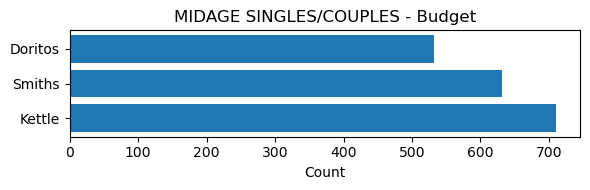

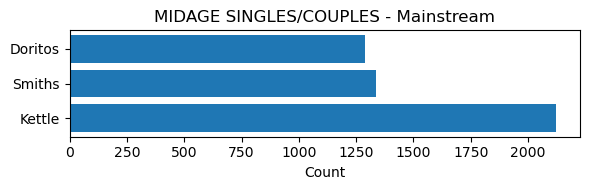

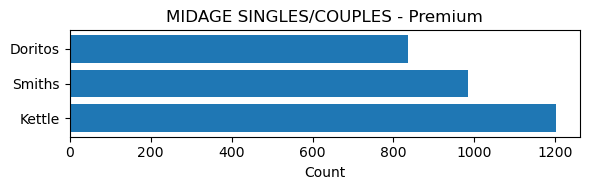

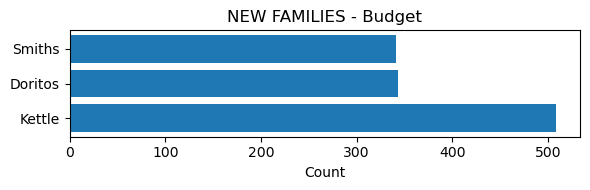

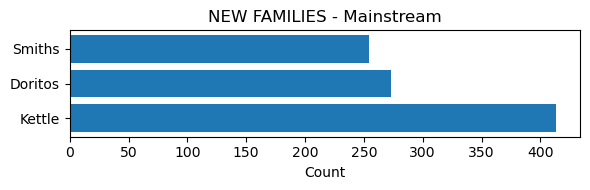

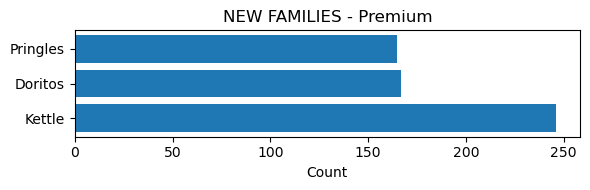

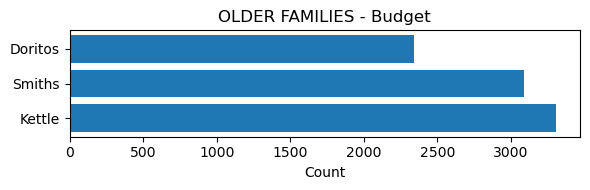

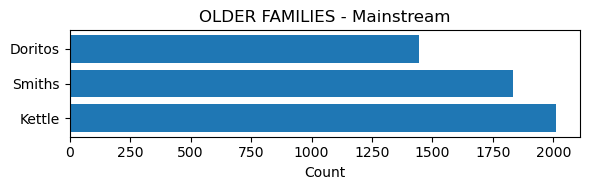

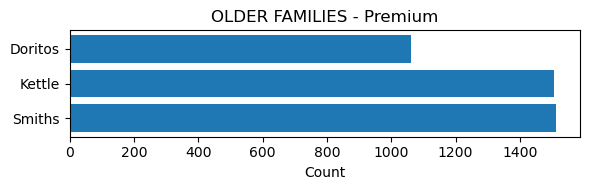

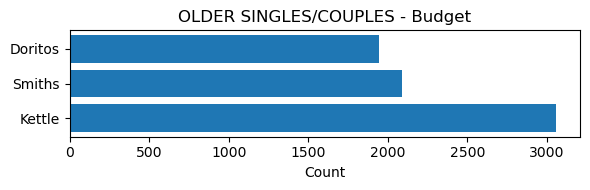

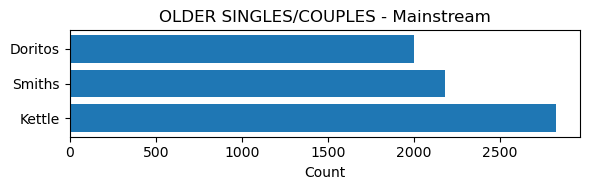

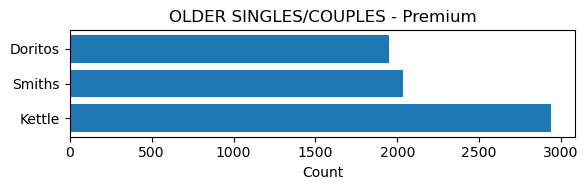

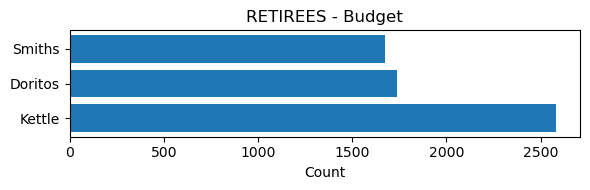

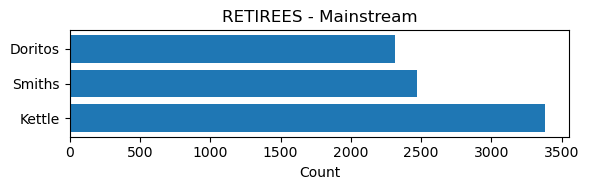

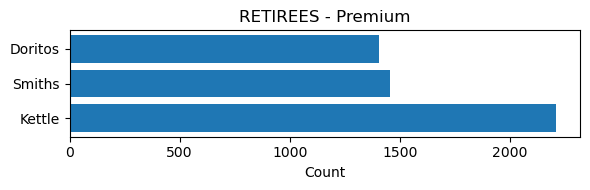

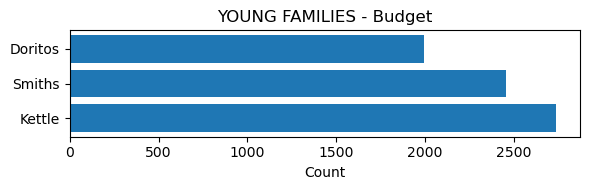

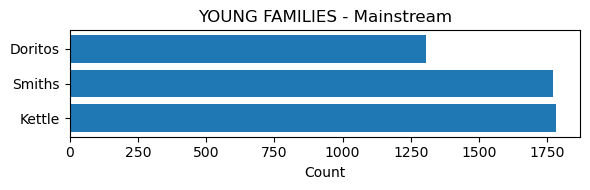

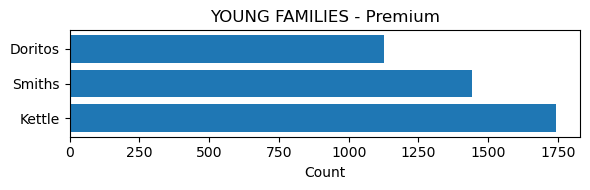

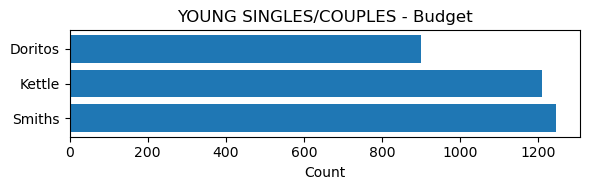

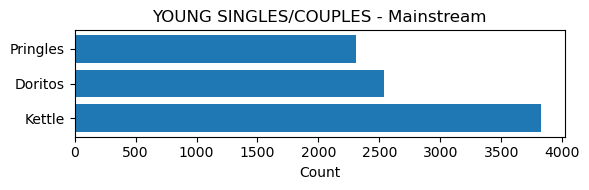

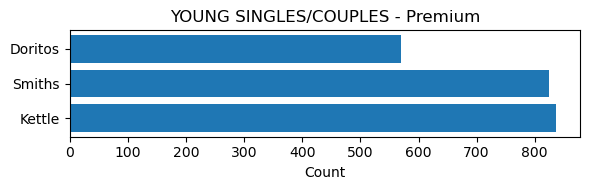

In [128]:
top_brands = (
    merged_df
    .groupby(["LIFESTAGE", "PREMIUM_CUSTOMER","cleaned_brand_name"])
    .size()
    .reset_index(name="count")
    .sort_values(["LIFESTAGE", "PREMIUM_CUSTOMER", "count"], ascending=[True, True, False])
)

top_brands = top_brands.groupby(["LIFESTAGE", "PREMIUM_CUSTOMER"]).head(3)

for (stage, prem), group in top_brands.groupby(["LIFESTAGE", "PREMIUM_CUSTOMER"]):
    print(f"\n========== {stage} - {prem} ==========")
    print(group[["cleaned_brand_name", "count"]])

for (stage, prem), group in top_brands.groupby(["LIFESTAGE", "PREMIUM_CUSTOMER"]):
    plt.figure(figsize=(6,2))
    plt.barh(group["cleaned_brand_name"], group["count"])
    plt.title(f"{stage} - {prem}")
    plt.xlabel("Count")
    plt.tight_layout()
    plt.show()


Kettle is the dominant brand across almost all customer segments, consistently ranking first, followed by Smiths and Doritos.
Family and older segments show strong loyalty toward Kettle and Smiths, indicating preference for trusted, mainstream brands.
Younger and mainstream segments (especially Young Singles/Mainstream) show more variety, with brands like Pringles appearing, suggesting openness to trendy or alternative options.

In [135]:
# Create segment column
merged_df["Segment"] = merged_df["LIFESTAGE"] + " - " + merged_df["PREMIUM_CUSTOMER"]

# Count occurrences
segment_brand = (
    merged_df
    .groupby(["Segment", "cleaned_brand_name"])
    .size()
    .reset_index(name="Count")
)

# Calculate percentage within each segment
segment_brand["Percentage"] = (
    segment_brand["Count"] /
    segment_brand.groupby("Segment")["Count"].transform("sum")
) * 100

# Sort values
segment_brand = segment_brand.sort_values(
    ["Segment", "Percentage"],
    ascending=[True, False]
)

# Show top 3 brands per segment
top3 = segment_brand.groupby("Segment").head(3)

print(top3)

                                 Segment cleaned_brand_name  Count  Percentage
9        MIDAGE SINGLES/COUPLES - Budget             Kettle    710   14.174486
14       MIDAGE SINGLES/COUPLES - Budget             Smiths    631   12.597325
5        MIDAGE SINGLES/COUPLES - Budget            Doritos    532   10.620882
30   MIDAGE SINGLES/COUPLES - Mainstream             Kettle   2121   17.909314
35   MIDAGE SINGLES/COUPLES - Mainstream             Smiths   1335   11.272482
..                                   ...                ...    ...         ...
404   YOUNG SINGLES/COUPLES - Mainstream            Doritos   2538   12.192544
411   YOUNG SINGLES/COUPLES - Mainstream           Pringles   2311   11.102037
429      YOUNG SINGLES/COUPLES - Premium             Kettle    836   13.324833
434      YOUNG SINGLES/COUPLES - Premium             Smiths    825   13.149506
425      YOUNG SINGLES/COUPLES - Premium            Doritos    570    9.085113

[63 rows x 4 columns]


1. Family and mainstream segments are the biggest contributors to chip sales, with Kettle being the most preferred brand across nearly all groups.
2. Marketing campaigns should focus on promoting Kettle to families while targeting younger mainstream customers with brands like Pringles and Doritos.

In [136]:
merged_pack = pd.concat([merged_df, pack_sizes.rename("Pack_Size")], axis=1)

========== YOUNG SINGLES/COUPLES - Premium ==========
Pack_Size
134.0     536
150.0     997
175.0    1614
Name: count, dtype: int64


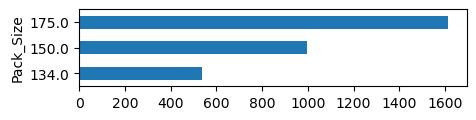

========== YOUNG SINGLES/COUPLES - Mainstream ==========
Pack_Size
134.0    2311
150.0    3233
175.0    4989
Name: count, dtype: int64


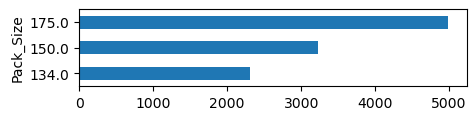

========== YOUNG SINGLES/COUPLES - Budget ==========
Pack_Size
134.0     830
150.0    1503
175.0    2334
Name: count, dtype: int64


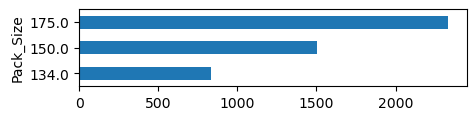

========== YOUNG FAMILIES - Premium ==========
Pack_Size
134.0    1002
150.0    1910
175.0    2995
Name: count, dtype: int64


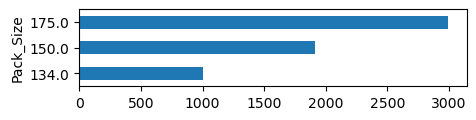

========== YOUNG FAMILIES - Mainstream ==========
Pack_Size
134.0    1145
150.0    2172
175.0    3163
Name: count, dtype: int64


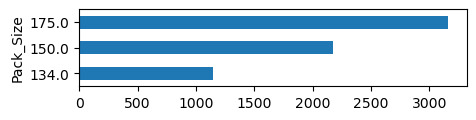

========== YOUNG FAMILIES - Budget ==========
Pack_Size
134.0    1670
150.0    3091
175.0    4909
Name: count, dtype: int64


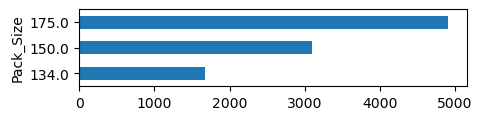

========== OLDER SINGLES/COUPLES - Premium ==========
Pack_Size
134.0    1744
150.0    2947
175.0    4444
Name: count, dtype: int64


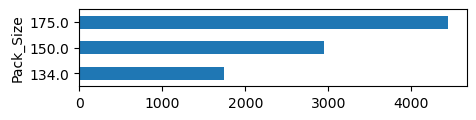

========== OLDER SINGLES/COUPLES - Mainstream ==========
Pack_Size
134.0    1718
150.0    2982
175.0    4514
Name: count, dtype: int64


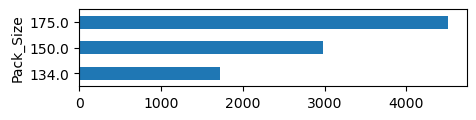

========== OLDER SINGLES/COUPLES - Budget ==========
Pack_Size
134.0    1841
150.0    2981
175.0    4611
Name: count, dtype: int64


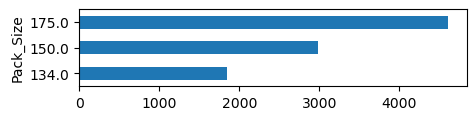

========== MIDAGE SINGLES/COUPLES - Premium ==========
Pack_Size
134.0     780
150.0    1327
175.0    2076
Name: count, dtype: int64


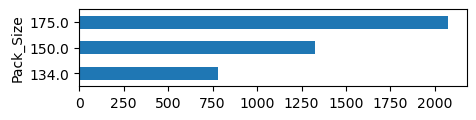

========== MIDAGE SINGLES/COUPLES - Mainstream ==========
Pack_Size
134.0    1156
150.0    1875
175.0    2962
Name: count, dtype: int64


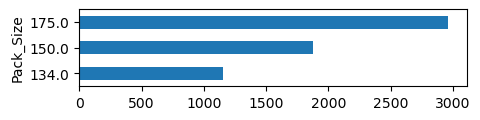

========== MIDAGE SINGLES/COUPLES - Budget ==========
Pack_Size
134.0     448
150.0     843
175.0    1275
Name: count, dtype: int64


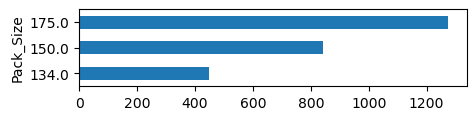

========== NEW FAMILIES - Premium ==========
Pack_Size
134.0    165
150.0    252
175.0    375
Name: count, dtype: int64


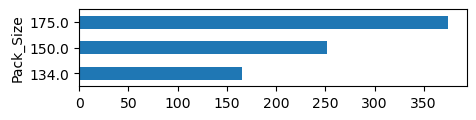

========== NEW FAMILIES - Mainstream ==========
Pack_Size
134.0    224
150.0    395
175.0    589
Name: count, dtype: int64


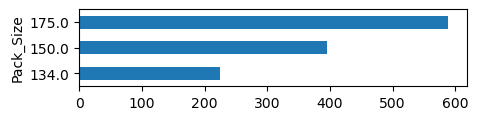

========== NEW FAMILIES - Budget ==========
Pack_Size
134.0    309
150.0    463
175.0    775
Name: count, dtype: int64


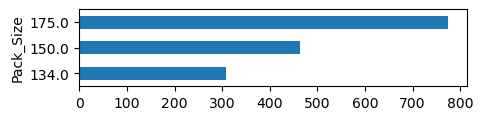

========== OLDER FAMILIES - Premium ==========
Pack_Size
134.0    1009
150.0    1812
175.0    2806
Name: count, dtype: int64


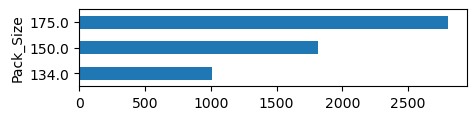

========== OLDER FAMILIES - Mainstream ==========
Pack_Size
134.0    1231
150.0    2354
175.0    3576
Name: count, dtype: int64


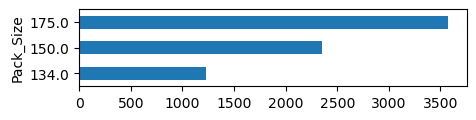

========== OLDER FAMILIES - Budget ==========
Pack_Size
134.0    1992
150.0    3878
175.0    5796
Name: count, dtype: int64


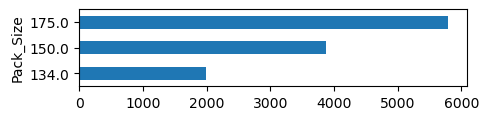

========== RETIREES - Premium ==========
Pack_Size
134.0    1329
150.0    2075
175.0    3295
Name: count, dtype: int64


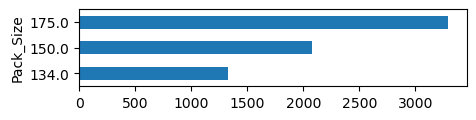

========== RETIREES - Mainstream ==========
Pack_Size
134.0    2100
150.0    3519
175.0    5290
Name: count, dtype: int64


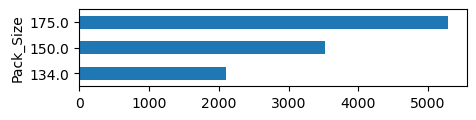

========== RETIREES - Budget ==========
Pack_Size
134.0    1512
150.0    2454
175.0    3833
Name: count, dtype: int64


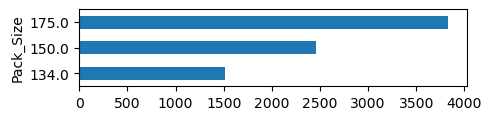

In [140]:
for stage in merged_df["LIFESTAGE"].unique():
    for prem in merged_df["PREMIUM_CUSTOMER"].unique():

        print('==========',stage, '-', prem,'==========')

        summary = merged_pack[
        (merged_pack["LIFESTAGE"] == stage) &
        (merged_pack["PREMIUM_CUSTOMER"] == prem)]["Pack_Size"].value_counts().head(3).sort_index()
        print(summary)
        plt.figure()
        summary.plot.barh(figsize=(5,1))
        plt.show()



In [142]:
temp = merged_df.reset_index().rename(columns={"index": "transaction"})

In [144]:
(temp.groupby(["LIFESTAGE", "PREMIUM_CUSTOMER"])["PROD_QTY"].sum()/temp.groupby(["LIFESTAGE", "PREMIUM_CUSTOMER"])["LYLTY_CARD_NBR"].nunique()).sort_values(ascending=False)

LIFESTAGE               PREMIUM_CUSTOMER
OLDER FAMILIES          Mainstream          9.740728
                        Budget              9.586310
                        Premium             9.510114
YOUNG FAMILIES          Budget              9.182972
                        Premium             9.162762
                        Mainstream          9.126100
OLDER SINGLES/COUPLES   Premium             7.119579
                        Budget              7.105295
                        Mainstream          7.064909
MIDAGE SINGLES/COUPLES  Mainstream          6.754790
RETIREES                Budget              6.422542
                        Premium             6.397211
MIDAGE SINGLES/COUPLES  Premium             6.354998
                        Budget              6.279920
RETIREES                Mainstream          6.230900
NEW FAMILIES            Mainstream          5.065960
                        Premium             5.013605
                        Budget              4.998201
YOUNG

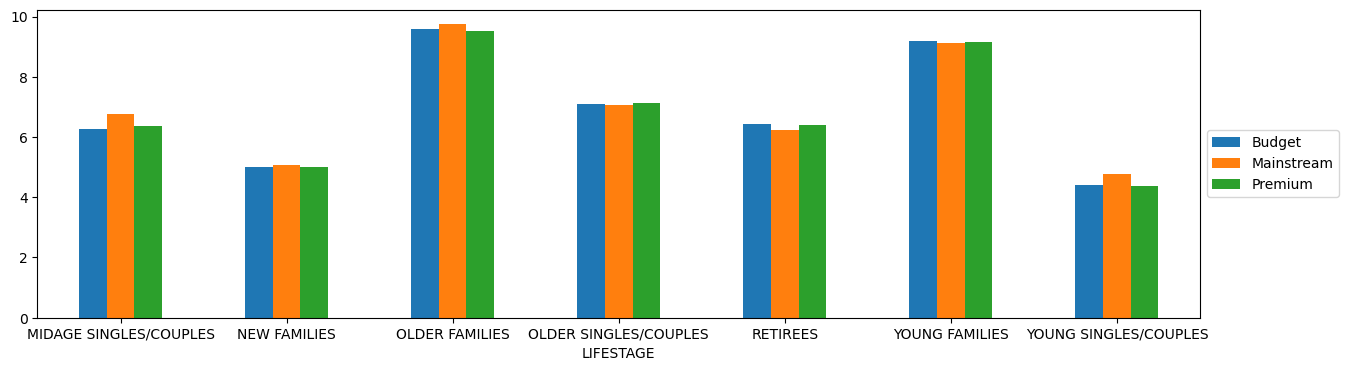

In [145]:

(temp.groupby(["LIFESTAGE", "PREMIUM_CUSTOMER"])["PROD_QTY"].sum() / temp.groupby(["LIFESTAGE", "PREMIUM_CUSTOMER"])["LYLTY_CARD_NBR"].nunique()).unstack().plot.bar(figsize=(15,4), rot=0)
plt.legend(loc="center left", bbox_to_anchor=(1.0, 0.5))
plt.savefig("Average purchase quantity per segment.png", bbox_inches="tight")
     

In [151]:
temp = merged_df.copy()

temp["Segment"] = temp["LIFESTAGE"] + " - " + temp["PREMIUM_CUSTOMER"]

temp = temp[temp["PROD_QTY"] != 0]

temp["Avg_price"] = temp["TOT_SALES"] / temp["PROD_QTY"]

avg_price_segment = temp.groupby("Segment")["Avg_price"].mean().sort_values(ascending=False)

print(avg_price_segment)

Segment
YOUNG SINGLES/COUPLES - Mainstream     4.070539
MIDAGE SINGLES/COUPLES - Mainstream    3.998501
RETIREES - Budget                      3.922946
RETIREES - Premium                     3.919845
NEW FAMILIES - Budget                  3.918038
NEW FAMILIES - Mainstream              3.916114
OLDER SINGLES/COUPLES - Premium        3.885567
OLDER SINGLES/COUPLES - Budget         3.875010
NEW FAMILIES - Premium                 3.870951
RETIREES - Mainstream                  3.832443
OLDER SINGLES/COUPLES - Mainstream     3.801915
YOUNG FAMILIES - Budget                3.752030
MIDAGE SINGLES/COUPLES - Premium       3.751451
YOUNG FAMILIES - Premium               3.751446
OLDER FAMILIES - Budget                3.731070
MIDAGE SINGLES/COUPLES - Budget        3.727780
OLDER FAMILIES - Mainstream            3.725506
YOUNG FAMILIES - Mainstream            3.705352
OLDER FAMILIES - Premium               3.703249
YOUNG SINGLES/COUPLES - Premium        3.645266
YOUNG SINGLES/COUPLES - Budget  

In [156]:
z = (
    temp.groupby(["Segment", "cleaned_brand_name"])["TOT_SALES"]
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

z[z["Segment"] == "YOUNG SINGLES/COUPLES - Mainstream"]

,Segment,cleaned_brand_name,TOT_SALES
0,YOUNG SINGLES/COUPLES - Mainstream,Kettle,35102.8
8,YOUNG SINGLES/COUPLES - Mainstream,Doritos,21655.6
23,YOUNG SINGLES/COUPLES - Mainstream,Pringles,15932.2
24,YOUNG SINGLES/COUPLES - Mainstream,Smiths,15196.1
55,YOUNG SINGLES/COUPLES - Mainstream,Infuzions,8730.4
60,YOUNG SINGLES/COUPLES - Mainstream,Old,8114.1
65,YOUNG SINGLES/COUPLES - Mainstream,Twisties,7499.6
72,YOUNG SINGLES/COUPLES - Mainstream,Tostitos,7216.0
73,YOUNG SINGLES/COUPLES - Mainstream,Thins,7200.6
92,YOUNG SINGLES/COUPLES - Mainstream,Cobs,6114.2


## Trends and Insights :

Top 3 total sales contributor segment are

* Older families (Budget) $156,864 
* Young Singles/Couples (Mainstream) $147,582
* Retirees (Mainstream) $145,169

1. Young Singles/Couples (Mainstream) has the highest population, followed by Retirees (Mainstream). Which explains their high total sales.

2. Despite Older Families not having the highest population, they have the highest frequency of purchase, which contributes to their high total sales.

3. Older Families followed by Young Families has the highest average quantity of chips bought per purchase.

4. The Mainstream category of the "Young and Midage Singles/Couples" have the highest spending of chips per purchase. And the difference to the non-Mainstream "Young and Midage Singles/Couples" are statistically significant.

5. Chips brand Kettle is dominating every segment as the most purchased brand.

6. Observing the 2nd most purchased brand, "Young and Midage Singles/Couples" is the only segment with a different preference (Doritos) as compared to others' (Smiths).

7. Most frequent chip size purchased is 175gr followed by the 150gr chip size for all segments.

## Views and Recommendations:

1. Older Families: Focus on the Budget segment. Strength: Frequent purchase. We can give promotions that encourages more frequency of purchase. Strength: High quantity of chips purchased per visit. We can give promotions that encourage them to buy more quantity of chips per purchase.

2. Young Singles/Couples: Focus on the Mainstream segment. This segment is the only segment that had Doritos as their 2nd most purchased brand (after Kettle). To specifically target this segment it might be a good idea to collaborate with Doritos merchant to do some branding promotion catered to "Young Singles/Couples - Mainstream" segment. Strength: Population quantity. We can spend more effort on making sure our promotions reach them, and it reaches them frequently.

3. Retirees: Focus on the Mainstream segment. Strength: Population quantity. Again, since their population quantity is the contributor to the high total sales, we should spend more effort on making sure our promotions reaches as many of them as possible and frequent.

4. General: All segments has Kettle as the most frequently purchased brand, and 175gr (regardless of brand) followed by 150gr as the preferred chip size. When promoting chips in general to all segments it is good to take advantage of these two points.